Task 1: Create a bar chart or histogram to visualize the distribution of a categorical or continuous variable, such as the distribution of ages or genders in a population.

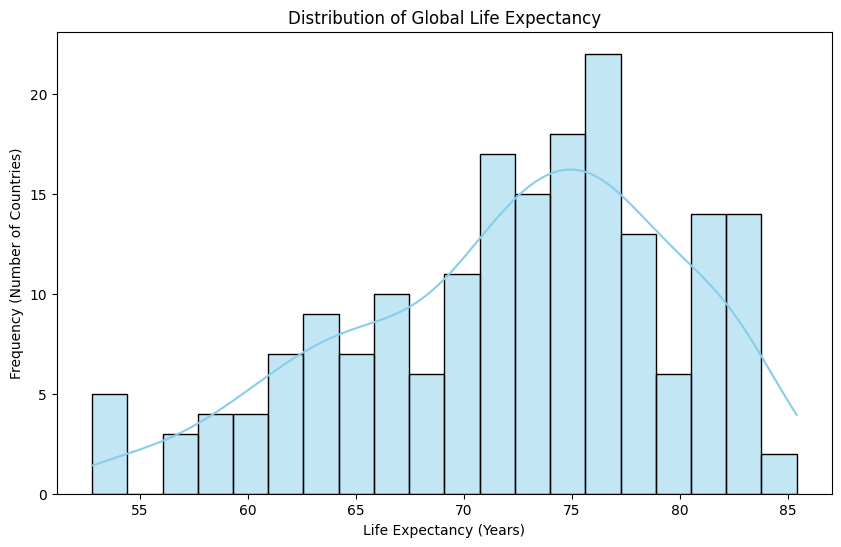

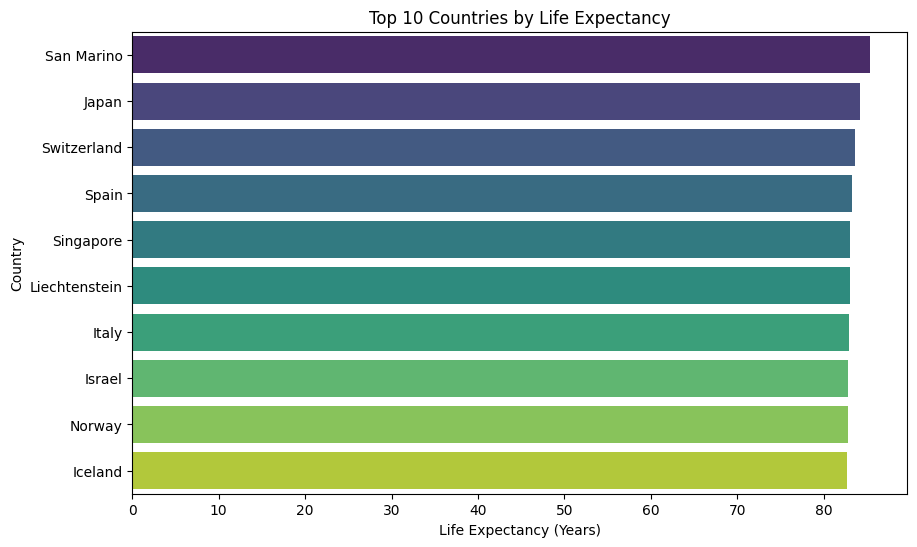

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('world_data_2023.csv')

# --- 1. Histogram: Distribution of Life Expectancy ---
df_life = df.dropna(subset=['Life expectancy'])

plt.figure(figsize=(10, 6))
sns.histplot(df_life['Life expectancy'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Global Life Expectancy')
plt.xlabel('Life Expectancy (Years)')
plt.ylabel('Frequency (Number of Countries)')
plt.show()

# --- 2. Bar Chart: Top 10 Countries by Life Expectancy ---
plt.figure(figsize=(10, 6))
top_10_life = df_life.sort_values(by='Life expectancy', ascending=False).head(10)

# Added 'hue' and 'legend=False' to fix the warning
sns.barplot(data=top_10_life, x='Life expectancy', y='Country', hue='Country', palette='viridis', legend=False)
plt.title('Top 10 Countries by Life Expectancy')
plt.xlabel('Life Expectancy (Years)')
plt.ylabel('Country')
plt.show()

Task 2: Perform data cleaning and exploratory data analysis (EDA) on a dataset of your choice, such as the Titanic dataset from Kaggle. Explore the relationships between variables and identify patterns and trends in the data.

Missing values before cleaning:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
dtype: int64


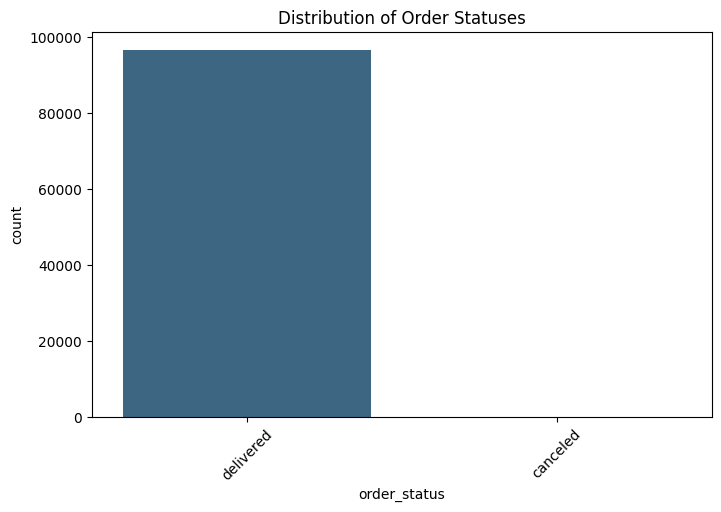

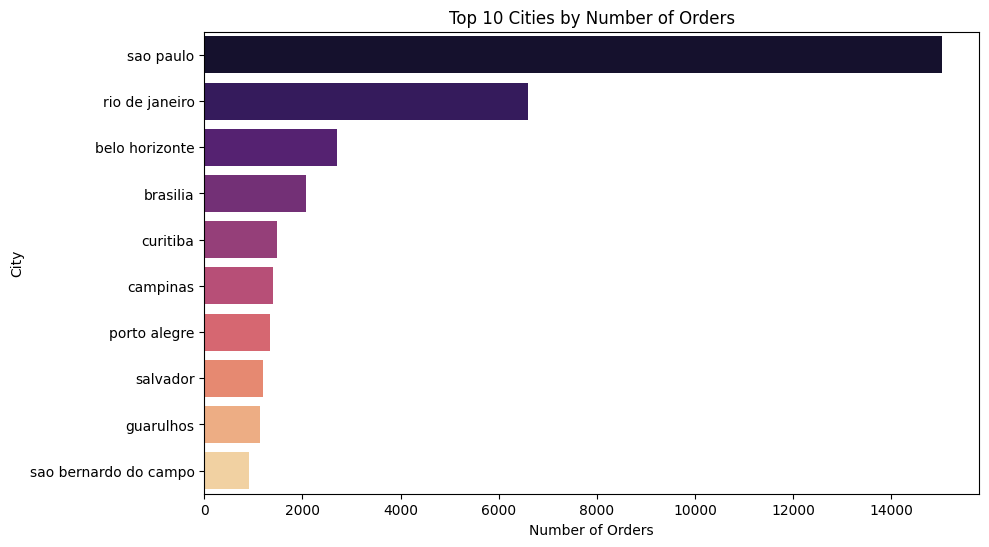

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

# --- Data Cleaning ---
df_merged = pd.merge(orders, customers, on='customer_id', how='inner')

print("Missing values before cleaning:\n", df_merged.isnull().sum())

# Added .copy() to fix the SettingWithCopyWarning
df_cleaned = df_merged.dropna(subset=['order_approved_at', 'order_delivered_customer_date']).copy()

df_cleaned['order_purchase_timestamp'] = pd.to_datetime(df_cleaned['order_purchase_timestamp'])

# --- Exploratory Data Analysis (EDA) ---
# 1. Distribution of Order Status
plt.figure(figsize=(8, 5))
# Added 'hue' and 'legend=False'
sns.countplot(data=df_cleaned, x='order_status', hue='order_status', palette='viridis', legend=False)
plt.title('Distribution of Order Statuses')
plt.xticks(rotation=45)
plt.show()

# 2. Top 10 Customer Cities by Order Volume
plt.figure(figsize=(10, 6))
top_cities = df_cleaned['customer_city'].value_counts().head(10)
# Added 'hue' and 'legend=False'
sns.barplot(x=top_cities.values, y=top_cities.index, hue=top_cities.index, palette='magma', legend=False)
plt.title('Top 10 Cities by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('City')
plt.show()

Task 3:Build a decision tree classifier to predict whether a customer will purchase a product or service based on their demographic and behavioral data. Use a dataset from the UCI Machine Learning Repository.


Accuracy: 0.88

Classification Report:
               precision    recall  f1-score   support

       False       0.90      0.97      0.93      2055
        True       0.74      0.47      0.57       411

    accuracy                           0.88      2466
   macro avg       0.82      0.72      0.75      2466
weighted avg       0.87      0.88      0.87      2466



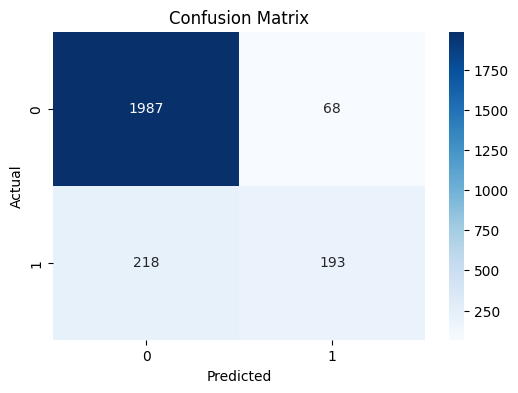

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('online_shoppers_intention.csv')

# Encode categorical variables (e.g., Month, VisitorType, Weekend)
le = LabelEncoder()
df['Month'] = le.fit_transform(df['Month'])
df['VisitorType'] = le.fit_transform(df['VisitorType'])
df['Weekend'] = le.fit_transform(df['Weekend'])

# Define Features (X) and Target (y)
# Target is 'Revenue' (Boolean: True if purchased, False if not)
X = df.drop('Revenue', axis=1)
y = df['Revenue']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=5, random_state=42) # Limiting depth prevents overfitting
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Task 4: Analyze and visualize sentiment patterns in social media data to understand public opinion and attitudes towards specific topics or brands.

Calculating sentiment for Tweets...
Done!


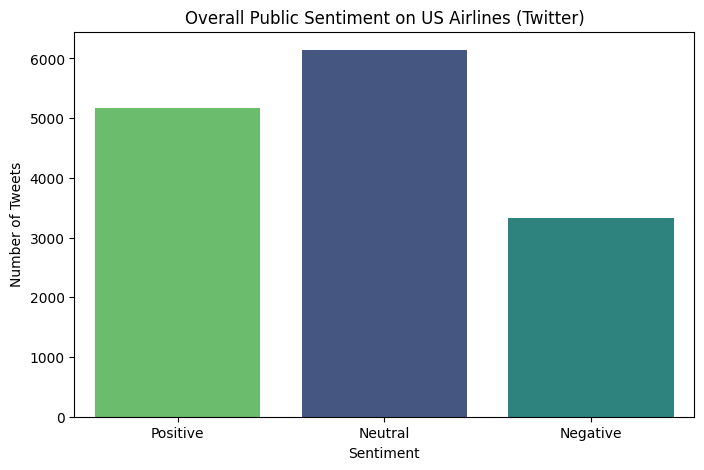

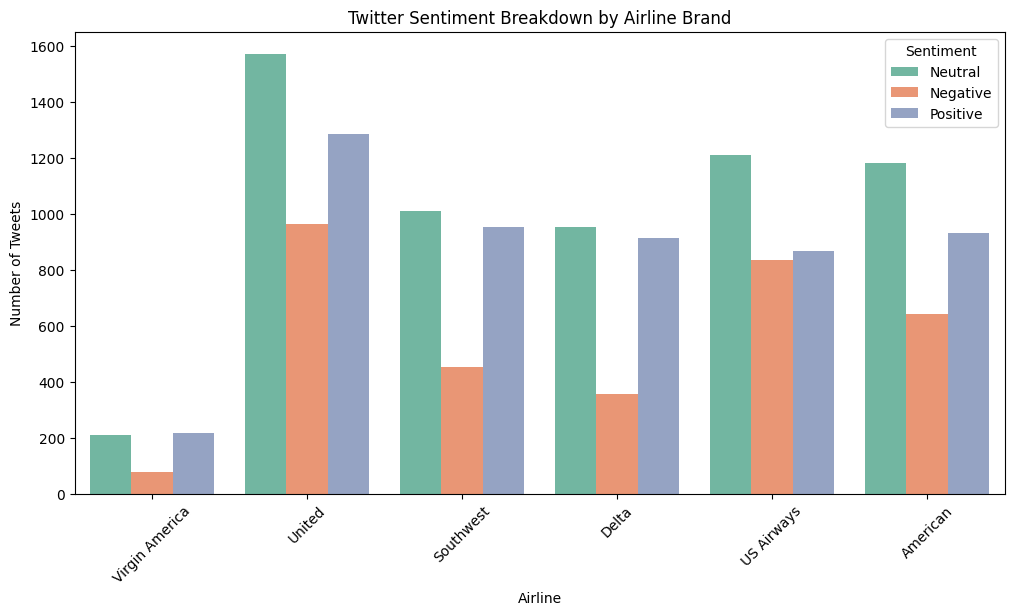

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

# 1. Load the Data
# Ensure the file is uploaded to Colab as 'Tweets.csv'
df = pd.read_csv('Tweets.csv')

# 2. Clean the Data
# We only need the airline brand and the text of the tweet
df_clean = df[['airline', 'text']].dropna().copy()

# 3. Sentiment Analysis Function
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

def categorize_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

print("Calculating sentiment for Tweets...")
# Compute sentiment (will only take a few seconds)
df_clean['sentiment_score'] = df_clean['text'].apply(get_sentiment)
df_clean['sentiment_category'] = df_clean['sentiment_score'].apply(categorize_sentiment)
print("Done!")

# 4. Visualizations
# Plot 1: Overall Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='sentiment_category',
              order=['Positive', 'Neutral', 'Negative'],
              palette='viridis', hue='sentiment_category', legend=False)
plt.title('Overall Public Sentiment on US Airlines (Twitter)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

# Plot 2: Sentiment Breakdown by Airline Brand
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, x='airline', hue='sentiment_category', palette='Set2')
plt.title('Twitter Sentiment Breakdown by Airline Brand')
plt.xlabel('Airline')
plt.ylabel('Number of Tweets')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.show()